          Total_Tokens(WS)  Unique_Types(WS)  TTR(WS)  Total_Tokens(KoBERT)  \
Dataset                                                                       
Wellness            127818             22367   0.1750                263712   
Chatbot              16932              6325   0.3736                 34776   
Subject            7510868            787477   0.1048              16024775   

          Unique_Types(KoBERT)  TTR(KoBERT)  
Dataset                                      
Wellness                  3567       0.0135  
Chatbot                   2433       0.0700  
Subject                   8958       0.0006  


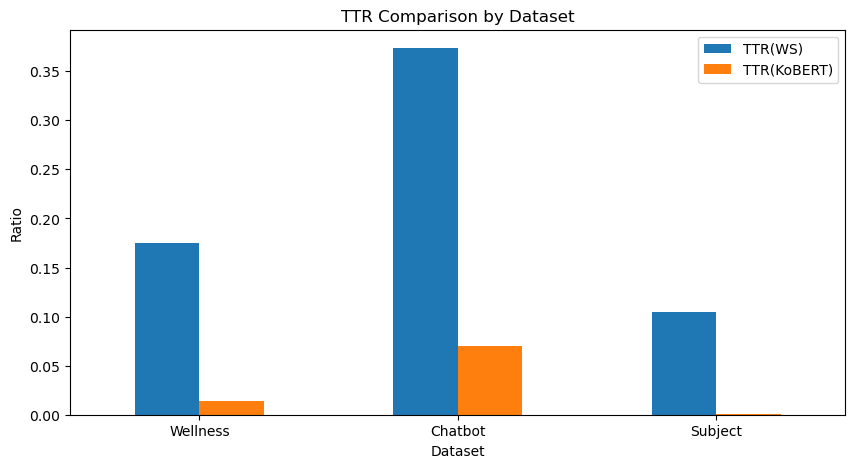

In [1]:
import pandas as pd
from transformers import AutoTokenizer

# 1. 토크나이저 로드 (기존 사용하시던 KoBERT)
tokenizer = AutoTokenizer.from_pretrained('monologg/kobert', trust_remote_code=True)

def get_ttr_stats(df, column_name='utterance'):
    """
    데이터프레임의 특정 컬럼에 대해 TTR 통계를 계산합니다.
    """
    texts = df[column_name].dropna().astype(str).tolist()
    
    # --- 1. 어절 단위 (Whitespace) ---
    ws_tokens = []
    for text in texts:
        ws_tokens.extend(text.split())
    
    ttr_ws = len(set(ws_tokens)) / len(ws_tokens) if ws_tokens else 0
    
    # --- 2. KoBERT 단위 (Subword) ---
    kb_tokens = []
    for text in texts:
        kb_tokens.extend(tokenizer.tokenize(text))
        
    ttr_kb = len(set(kb_tokens)) / len(kb_tokens) if kb_tokens else 0
    
    return {
        'Total_Tokens(WS)': len(ws_tokens),
        'Unique_Types(WS)': len(set(ws_tokens)),
        'TTR(WS)': round(ttr_ws, 4),
        'Total_Tokens(KoBERT)': len(kb_tokens),
        'Unique_Types(KoBERT)': len(set(kb_tokens)),
        'TTR(KoBERT)': round(ttr_kb, 4)
    }

# 2. 데이터 로드 및 계산
datasets = {
    "Wellness": pd.read_csv("cleaned_wellness.csv"),
    "Chatbot": pd.read_csv("cleaned_chatbot.csv"),
    "Subject": pd.read_csv("cleaned_subject.csv")
}

ttr_results = []
for name, df in datasets.items():
    stats = get_ttr_stats(df)
    stats['Dataset'] = name
    ttr_results.append(stats)

# 3. 결과 출력
ttr_df = pd.DataFrame(ttr_results).set_index('Dataset')
print(ttr_df)

# 시각화 (Optional)
ttr_df[['TTR(WS)', 'TTR(KoBERT)']].plot(kind='bar', figsize=(10, 5), rot=0)
import matplotlib.pyplot as plt
plt.title("TTR Comparison by Dataset")
plt.ylabel("Ratio")
plt.show()

          Total Tokens  Unique Types     TTR
Dataset                                     
Wellness        127818         22367  0.1750
Chatbot          16932          6325  0.3736
Subject        7510868        787477  0.1048


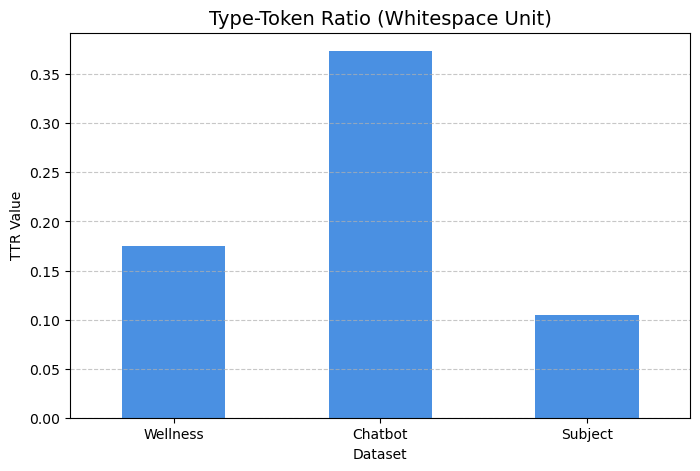

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def get_ws_ttr(df, column_name='utterance'):
    """
    공백(Whitespace) 기준으로 분리된 어절의 TTR을 계산합니다.
    """
    # 1. 텍스트 데이터 추출 (결측치 제거 및 문자열 변환)
    texts = df[column_name].dropna().astype(str).tolist()
    
    # 2. 전체 어절(Tokens) 리스트 생성
    all_tokens = []
    for text in texts:
        all_tokens.extend(text.split())
    
    # 3. 고유 어절(Types) 추출
    unique_types = set(all_tokens)
    
    # 4. TTR 계산 (Unique Types / Total Tokens)
    total_tokens_count = len(all_tokens)
    unique_types_count = len(unique_types)
    ttr = unique_types_count / total_tokens_count if total_tokens_count > 0 else 0
    
    return {
        'Total Tokens': total_tokens_count,
        'Unique Types': unique_types_count,
        'TTR': round(ttr, 4)
    }

# 데이터 로드
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

results = []
for name, file in files.items():
    try:
        df = pd.read_csv(file)
        stats = get_ws_ttr(df)
        stats['Dataset'] = name
        results.append(stats)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")

# 결과 출력 및 시각화
ttr_df = pd.DataFrame(results).set_index('Dataset')
print(ttr_df)

# 시각화
ttr_df['TTR'].plot(kind='bar', color='#4A90E2', figsize=(8, 5), rot=0)
plt.title('Type-Token Ratio (Whitespace Unit)', fontsize=14)
plt.ylabel('TTR Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

데이터셋 분석 중...

[ TTR 분석 결과 ]
           Total Tokens  Unique Types     TTR
Dataset                                      
dataset_1        252594         58198  0.2304
dataset_2        226413         51506  0.2275
dataset_3        133209         24452  0.1836
dataset_4        150141         28331  0.1887


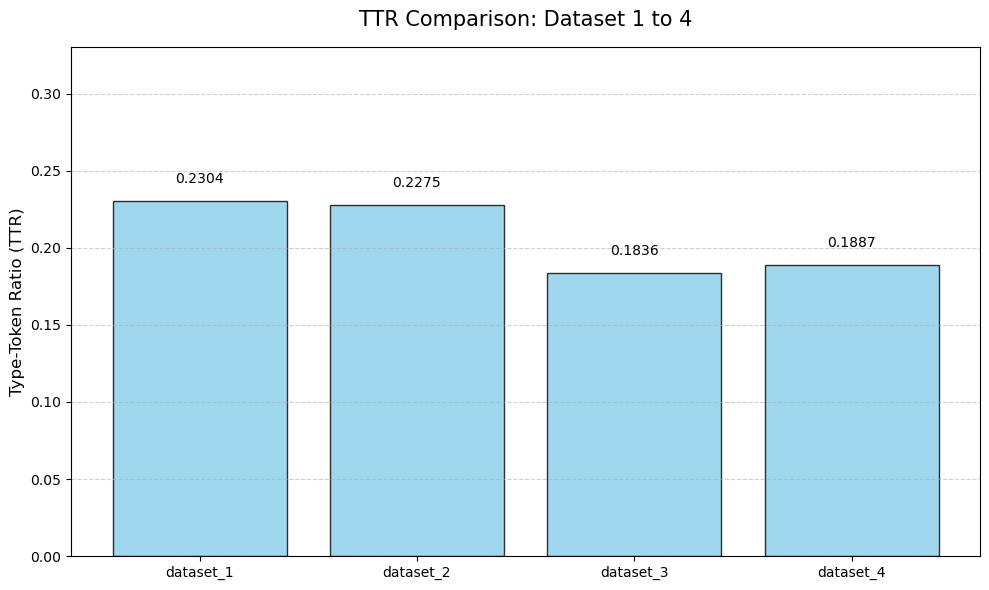

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def get_ws_ttr(df, column_name='utterance'):
    """공백(Whitespace) 기준으로 TTR을 계산하는 함수"""
    # 결측치 제거 및 문자열 변환
    texts = df[column_name].dropna().astype(str).tolist()
    
    # 전체 어절(Tokens) 추출
    all_tokens = []
    for text in texts:
        all_tokens.extend(text.split())
    
    total_tokens_count = len(all_tokens)
    unique_types_count = len(set(all_tokens))
    
    # TTR 계산
    ttr = unique_types_count / total_tokens_count if total_tokens_count > 0 else 0
    return total_tokens_count, unique_types_count, round(ttr, 4)

# 1. 분석할 파일 리스트 정의
file_names = ['dataset_1.csv', 'dataset_2.csv', 'dataset_3.csv', 'dataset_4.csv']
results = []

print("데이터셋 분석 중...")

# 2. 반복문을 통한 데이터 처리
for file in file_names:
    try:
        df = pd.read_csv(file)
        # 만약 컬럼명이 'utterance'가 아니라면 실제 컬럼명으로 수정하세요.
        total, unique, ttr_val = get_ws_ttr(df, column_name='utterance')
        
        results.append({
            'Dataset': file.split('.')[0], # 파일명에서 확장자 제거
            'Total Tokens': total,
            'Unique Types': unique,
            'TTR': ttr_val
        })
    except FileNotFoundError:
        print(f"⚠️ 파일을 찾을 수 없습니다: {file}")
    except Exception as e:
        print(f"⚠️ {file} 처리 중 오류 발생: {e}")

# 3. 결과 요약 데이터프레임 생성
ttr_df = pd.DataFrame(results).set_index('Dataset')
print("\n[ TTR 분석 결과 ]")
print(ttr_df)

# 4. 시각화
plt.figure(figsize=(10, 6))
bars = plt.bar(ttr_df.index, ttr_df['TTR'], color='skyblue', edgecolor='black', alpha=0.8)

# 막대 위에 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, yval, ha='center', va='bottom', fontsize=10)

plt.title('TTR Comparison: Dataset 1 to 4', fontsize=15, pad=15)
plt.ylabel('Type-Token Ratio (TTR)', fontsize=12)
plt.ylim(0, max(ttr_df['TTR']) + 0.1) # 상단 여유 공간
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()